# 3 — How the model is put together

Notebook 1 ran the model. This one explains **how it is built**, so you can assemble the setup *you*
want rather than copying someone else's:

- **`step` vs `integrate`** — what each is for, and why both exist.
- **What happens inside one timestep.**
- **Switching physics on and off** — can you run without sea ice? Without eddies? (Yes. Here's how.)
- **Building up**, one piece at a time, from a bare ocean to the full thing.
- **Real weather** — the same JRA55-do reanalysis the science runs use, on this tiny mesh.

Everything runs on the **pi** mesh (3,140 nodes) on a **CPU**. Sections 1–5 need **no data at all**.
Section 6 adds real atmospheric forcing, which does need a download — it says so when you get there.

In [1]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from fesom_jax.mesh import load_mesh
from fesom_jax.ssh import build_ssh_operator
from fesom_jax.step import step
from fesom_jax.integrate import integrate
from fesom_jax.diagnostics import state_diagnostics, format_diagnostics
from fesom_jax import ic

DT = 100.0                                   # the pi timestep (CFL-bound; see docs/NEW_MESH.md)

mesh   = load_mesh()                         # the packaged pi mesh
op     = build_ssh_operator(mesh, dt=DT)     # sea-surface-height solver — built ONCE, reused
state0 = ic.initial_state(mesh)              # idealized: uniform water + a warm blob
stress = jnp.zeros((mesh.elem2D, 2))         # no wind, for now

print(f"pi mesh: {mesh.nod2D} nodes, {mesh.nl} levels, dt = {DT:.0f} s")

pi mesh: 3140 nodes, 48 levels, dt = 100 s


---
## 1. `step` vs `integrate`

There are exactly two ways to advance the model, and the difference is worth understanding.

**`step(state, ...) -> state`** advances the ocean by **one** timestep. It is a *pure function*: it
takes a state and returns a new one. Nothing is hidden — no global variables, no mutation, no
internal clock. Everything it needs is an argument. That is what makes the whole model
differentiable.

**`integrate(state, ..., n_steps=N) -> state`** advances it by **N** timesteps, by calling `step`
inside a [`lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html).

You could just write a Python `for` loop over `step`. `integrate` exists because the scan does two
things a loop cannot:

1. **It compiles the timestep once**, not N times. A Python loop of 500 steps would unroll into 500
   copies of the timestep for the compiler to chew through.
2. **It checkpoints for the backward pass.** Reverse-mode differentiation normally has to remember
   every intermediate value from the forward run — for a long ocean run that is far more memory than
   any GPU has. The scan is wrapped in `jax.checkpoint`, so the backward pass *recomputes* each step
   instead of storing it.

They agree exactly, as they must:

In [2]:
# one step, by hand
s_manual = step(state0, mesh, op, stress, dt=DT, is_first_step=True)

# the same thing through integrate
s_integ = integrate(state0, mesh, op, stress, n_steps=1, dt=DT)

same = jnp.allclose(s_manual.T, s_integ.T) and jnp.allclose(s_manual.uv, s_integ.uv)
print("step(is_first_step=True)  ==  integrate(n_steps=1)  :", bool(same))

step(is_first_step=True)  ==  integrate(n_steps=1)  : True


### `is_first_step` — the one piece of bookkeeping you should know about

The model steps time with a scheme (Adams–Bashforth) that uses **the previous step's** tendencies as
well as this one's. On the very first step there is no previous step, so it has to start differently.
That is what `is_first_step=True` means.

`integrate` handles this for you: its first step runs with `is_first_step=True` and the rest go into
the scan. You only have to think about it if you drive `step` yourself — and if you resume from a
restart, the previous-step history comes back with it, so you pass `is_first_step=False`.

### Why the compile cost stops mattering

In [3]:
for n in (1, 200):
    t0 = time.time()
    s = integrate(state0, mesh, op, stress, n_steps=n, dt=DT)
    s.T.block_until_ready()
    el = time.time() - t0
    print(f"  {n:3d} steps: {el:5.1f} s total  ({1000 * el / n:6.1f} ms/step)")

print("\nThe first call pays for compiling the timestep. After that each step is cheap --")
print("which is why you run the model through integrate(), not a Python loop.")

    1 steps:   1.0 s total  ( 986.1 ms/step)


  200 steps:  11.4 s total  (  57.0 ms/step)

The first call pays for compiling the timestep. After that each step is cheap --
which is why you run the model through integrate(), not a Python loop.


---
## 2. What happens inside one timestep

`step()` runs the same sequence of operations FESOM does, in the same order:

| | what it does |
|---|---|
| **Layer geometry** | how thick is each layer right now (the surface moves, so this changes) |
| **Density & pressure** | equation of state → density → hydrostatic pressure → the pressure-gradient force |
| **Vertical mixing** | how strongly turbulence stirs heat and momentum downward (`kpp` / `tke` / simple `pp`) |
| **Momentum** | the velocity tendency: Coriolis, pressure gradient, friction, viscosity |
| **Sea-surface height** | an iterative (conjugate-gradient) solve for the new surface elevation |
| **Velocity & vertical velocity** | update the currents; get `w` from continuity |
| **Tracers** | advect temperature and salinity (a flux-corrected scheme), then diffuse them, plus eddy fluxes if GM is on |
| **Sea ice** | grow, melt and push the ice around — *only if there is an atmosphere to drive it* (§6) |

Every one of those is traced by JAX, which is why a gradient can flow back through all of it —
including the iterative surface solve.

---
## 3. Switching physics on and off

This is the part people ask about first: **can I run without sea ice? without eddies?** Yes. Each
piece of physics is selected by a config argument, and the rule is uniform:

> **`None` = that physics is OFF.  `SomeConfig()` = ON with defaults.  `SomeConfig(x=…)` = ON, tuned.**

| argument | `None` gives you | `Config()` gives you |
|---|---|---|
| `kpp_cfg` | simple (Pacanowski–Philander) vertical mixing | **KPP** boundary-layer mixing |
| `tke_cfg` | *(no TKE)* | prognostic **turbulent-kinetic-energy** mixing |
| `gm_cfg` | no eddy parameterization | **GM + Redi** — stirring by eddies too small to resolve |
| `ice_cfg` | **no sea ice at all** | prognostic **sea ice** (needs forcing — §6) |
| `ale_cfg` | linear free surface | **zstar** moving vertical coordinate |
| `visc_cfg` | default horizontal viscosity | tuned viscosity |

Two rules worth knowing:

- **`kpp` and `tke` are mutually exclusive** — the ocean runs exactly one vertical-mixing scheme.
- **`None` is not a slow no-op.** If a piece is off, its code is never traced, so the model is
  bit-for-bit what it would be if that feature did not exist. Switching things off costs nothing and
  changes nothing else.

The defaults are deliberately conservative — nothing is on unless you ask for it:

In [4]:
from fesom_jax.kpp import KppConfig
from fesom_jax.gm import GMConfig
from fesom_jax.ice import IceConfig
from fesom_jax.tke import TkeConfig
from fesom_jax.ale import AleConfig

# step() with no config arguments = the bare ocean. Nothing is silently switched on for you.
print("A bare step() runs with:  kpp=None  tke=None  gm=None  ice=None  ale=None")
print("i.e. simple PP mixing, no eddy parameterization, no sea ice, linear free surface.\n")
print("GMConfig defaults :", GMConfig())
print("KppConfig fields  :", KppConfig()._fields[:6], "...")

A bare step() runs with:  kpp=None  tke=None  gm=None  ice=None  ale=None
i.e. simple PP mixing, no eddy parameterization, no sea ice, linear free surface.

GMConfig defaults : GMConfig(redi=True, fer_gm=True, redi_ktaper=True, k_gm_min=2.0, redi_kmin=100.0, k_gm_cmin=0.1, k_gm_cm=3.0, refscalresol=100000.0, gmzexp_zref=500.0, gmzexp_smin=0.6, odm95_scr=0.002, odm95_sd=0.001, slope_eps=5e-06, gamma_bv_floor=1e-08, g=9.81, rho_ref=1030.0, k_gm_max=1000.0, redi_kmax_default=1000.0)
KppConfig fields  : ('double_diffusion', 'use_kpp_nonlclflx', 'smooth_blmc', 'smooth_hbl', 'use_sw_pene', 'epsln') ...


---
## 4. Building it up, one piece at a time

Same mesh, same initial state, same 100 steps — the only thing that changes is which physics is
switched on. Each run stays stable, and each differs from the bare ocean by a little.

In [5]:
SETUPS = [
    ("bare ocean (PP mixing)", dict()),
    ("+ GM/Redi eddies",       dict(gm_cfg=GMConfig())),
    ("+ zstar coordinate",     dict(gm_cfg=GMConfig(), ale_cfg=AleConfig())),
]

base = None
for name, cfg in SETUPS:
    t0 = time.time()
    s = integrate(state0, mesh, op, stress, n_steps=100, dt=DT, **cfg)
    s.T.block_until_ready()
    d = state_diagnostics(s, fields=["T", "S", "uv", "eta_n"])
    if base is None:
        base = s
        delta = "   (the reference)"
    else:                                   # how far did this config move the answer?
        dT  = float(jnp.max(jnp.abs(s.T - base.T)))
        duv = float(jnp.max(jnp.abs(s.uv - base.uv)))
        delta = f"   vs bare: max|dT|={dT:.2e} degC  max|d(uv)|={duv:.2e} m/s"
    print(f"{name:24s} {time.time()-t0:5.1f}s  max|uv|={d['max_abs_uv']:.4f}  "
          f"max|eta|={d['max_abs_eta']:.4f}{delta}")

print("\nAll finite, all stable -- each is a valid model, just a different one.")

bare ocean (PP mixing)     8.6s  max|uv|=0.0449  max|eta|=0.3451   (the reference)


+ GM/Redi eddies          15.0s  max|uv|=0.0449  max|eta|=0.3451   vs bare: max|dT|=1.12e-03 degC  max|d(uv)|=1.39e-06 m/s


+ zstar coordinate        15.6s  max|uv|=0.0449  max|eta|=0.3452   vs bare: max|dT|=3.16e-03 degC  max|d(uv)|=4.00e-05 m/s

All finite, all stable -- each is a valid model, just a different one.


Note how **small** those differences are. That is not a bug, and it is worth understanding rather than
glossing over: 100 steps is under three hours of ocean, the initial state is a smooth idealized blob,
and this mesh is far too coarse for eddies to do much. GM is a *slow* process — it reshapes density
surfaces over months, not hours. You are seeing the very beginning of its effect.

This is a general and slightly uncomfortable truth about ocean models: **most of the physics you
switch on will not visibly change a short run.** It changes the *climate* — the state the model
settles into after years. That is exactly why the calibration work in this project has to reckon with
slow targets, and why a short-window result can mislead you (see *Limitations* in the README).

Each of these is a legitimate model. Which you want depends on the question: a coarse mesh like this
cannot resolve eddies, so `gm_cfg` earns its place; on a mesh fine enough to resolve them you would
switch it off.

---
## 5. The pieces you *cannot* switch on yet — and the reason is physics, not software

Try to add **KPP** and it refuses:

In [6]:
try:
    integrate(state0, mesh, op, stress, n_steps=5, dt=DT, kpp_cfg=KppConfig())
except ValueError as e:
    print("KppConfig() ->", e)

try:
    integrate(state0, mesh, op, stress, n_steps=5, dt=DT, ice_cfg=IceConfig())
except ValueError as e:
    print("\nIceConfig() ->", e)

KppConfig() -> KPP (kpp_cfg) requires surface forcing (step_forcing): it needs heat_flux/water_flux/stress_node_surf/sw_3d for ustar/Bo/bfsfc — a boundary-layer scheme needs the boundary. Build the forcing with fesom_jax.surface_forcing.build_surface_forcing, or keep kpp_cfg=None for an unforced run.

IceConfig() -> ice_cfg was given but there is no forcing (step_forcings=None), so the sea-ice step would be silently skipped -- ice cannot grow or melt without an atmosphere. Either pass step_forcings=... (build them with fesom_jax.surface_forcing.build_surface_forcing), or drop ice_cfg.


This is the most useful thing in the notebook, so it is worth sitting with.

**KPP**, **TKE** and **sea ice** all need an **atmosphere**, and for the same underlying reason:

- **KPP and TKE are surface-boundary-layer schemes.** They model how wind stirs the upper ocean and
  how surface cooling drives convection. Their inputs are the *surface fluxes* — friction velocity
  from the wind, buoyancy flux from heating and evaporation. A boundary-layer scheme needs the
  boundary. With no weather there is no boundary layer to model, so they refuse rather than quietly
  computing nonsense.
- **Sea ice** grows, melts and drifts in response to freezing air, snowfall and sunlight. With no
  atmosphere there is nothing for it to respond to.

What *does* run unforced is the **interior**: advection, the pressure gradient, the surface-height
solve, eddy stirring, the vertical coordinate. That is the natural dividing line in an ocean model,
and once you see it the config table stops looking arbitrary.

So: to switch these on, give the model some weather.

---
## 6. Real weather — the actual JRA55-do reanalysis, on this tiny mesh

> ### ⚠️ From here on you need the forcing data
> This section reads **JRA55-do** — the real, observed atmosphere the science runs use. Get it with:
> ```bash
> python scripts/fetch_data.py --dest ~/fesom-data          # ~11 GB
> eval "$(python scripts/fetch_data.py --dest ~/fesom-data --print-env)"
> ```
> See [`docs/DATA.md`](../docs/DATA.md). Everything above needed nothing.

Two things change now, and they are what turns a demonstration into a model:

1. **A real initial state.** Instead of a warm blob, start from **observed** temperature and salinity
   (PHC 3.0) — plus sea ice wherever the water is already at freezing point. A PHC state for the pi
   mesh ships inside the package (2.3 MB), so this costs you no download.
2. **A real atmosphere.** `surface_forcing` reads JRA55-do and interpolates it onto the mesh at
   runtime — exactly as FESOM does, nothing is pre-computed to disk. It is completely
   **mesh-agnostic**: the same code drives this 3,140-node mesh and a 7-million-node one.

> **Use `cold_start_state()` — do not assemble a cold start by hand.** It loads the PHC
> temperature/salinity *and* seeds the sea ice, in one call. Splitting it into the two underlying
> steps is how you lose your sea ice: this project once shipped a driver that did the first step and
> silently dropped the second, so the model started ice-free and took months to grow any. One call,
> impossible to get half-right.

In [7]:
from pathlib import Path
import fesom_jax
from fesom_jax.phc_ic import cold_start_state
from fesom_jax import surface_forcing, paths

# 1. observed T/S + sea ice, in ONE call. cold_start_state is THE way to start a run:
#    it loads the PHC temperature/salinity AND seeds sea ice where the water is already
#    freezing. Doing those two steps by hand is a known way to lose your sea ice -- forget
#    the second and the model starts ice-free and takes months to grow any.
IC_PI = Path(fesom_jax.__file__).parent / "data" / "ic_pi"   # SHIPS with the package
real0 = cold_start_state(mesh, IC_PI)
sst0  = real0.T[:, 0]

print(f"observed initial state: SST {float(sst0.min()):.2f} .. {float(sst0.max()):.2f} degC")
print(f"sea ice seeded on {int((np.asarray(real0.a_ice) > 0.1).sum())} of {mesh.nod2D} nodes")

# 2. the real atmosphere. jra_dir resolves as: explicit arg > $FESOM_JRA_DIR > Levante default
print("forcing from:", paths.resolve("jra_dir"))
forcing = surface_forcing.build_surface_forcing(mesh, 1958, sst_ic=sst0)
print("JRA55-do ready")

observed initial state: SST -1.87 .. 29.67 degC
sea ice seeded on 1131 of 3140 nodes
forcing from: /pool/data/AWICM/FESOM2/FORCING/JRA55-do-v1.4.0


JRA55-do ready


### Now run the complete model

Observed ocean, real weather, KPP mixing, GM eddies, and **prognostic sea ice** — the same physics as
the science configuration, on a mesh small enough to run on a laptop.

In [8]:
N = 120                                            # 120 steps = 3.3 hours of ocean
dates = surface_forcing.dates_for_steps(1958, DT, N)
step_forcings = forcing.stack(dates)               # the weather at each step

t0 = time.time()
real = integrate(real0, mesh, op, stress, n_steps=N, dt=DT,
                 step_forcings=step_forcings, forcing_static=forcing.static,
                 kpp_cfg=KppConfig(), gm_cfg=GMConfig(), ice_cfg=IceConfig())   # <- ice, at last
real.T.block_until_ready()
print(f"full model + real JRA55: {N} steps in {time.time()-t0:.1f} s\n")

print(format_diagnostics(
    state_diagnostics(real, fields=["T", "S", "uv", "eta_n", "a_ice", "m_ice"]),
    label="pi, everything on, JRA55 1958"))

full model + real JRA55: 120 steps in 32.0 s

[diagnostics pi, everything on, JRA55 1958] FINITE  n_nonfinite=0
  max|uv|=0.5042  max|uvnode|=0.4743  max|w|=0.001076  max|eta|=1.339
  T[-2.01,29.7]  S[0,37.35]  a_ice_max=0.9089  m_ice_max=2


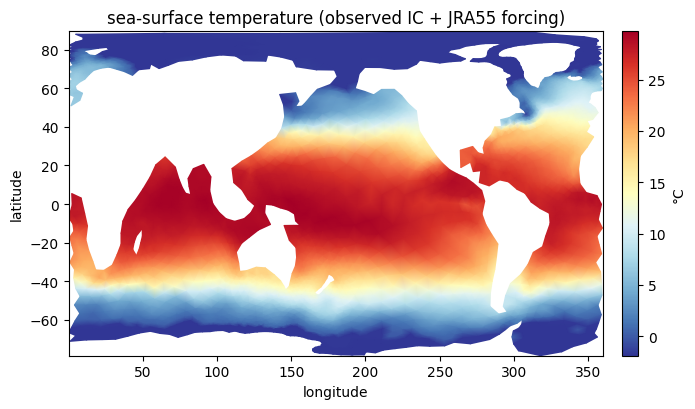

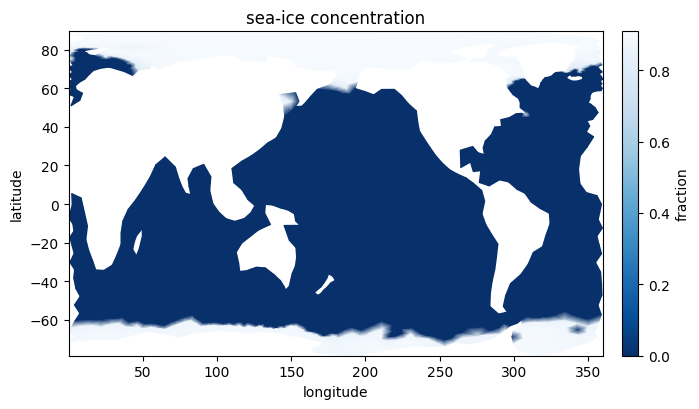

In [9]:
lon, lat = np.degrees(np.asarray(mesh.geo_coord_nod2D)).T
tris = np.asarray(mesh.elem_nodes)
wrap = np.abs(lon[tris] - lon[tris][:, [0]]).max(axis=1) > 180
triang = mtri.Triangulation(lon, lat, tris, mask=wrap)

def plot_field(v, title, cmap="viridis", units="", **kw):
    fig, ax = plt.subplots(figsize=(10, 4.2))
    t = ax.tripcolor(triang, np.asarray(v), cmap=cmap, shading="gouraud", **kw)
    fig.colorbar(t, ax=ax, label=units, pad=0.02)
    ax.set(title=title, xlabel="longitude", ylabel="latitude",
           xlim=(lon.min(), lon.max()), ylim=(lat.min(), lat.max()))
    ax.set_aspect(1.3); plt.tight_layout(); plt.show()

plot_field(real.T[:, 0], "sea-surface temperature (observed IC + JRA55 forcing)",
           cmap="RdYlBu_r", units="°C")
plot_field(real.a_ice, "sea-ice concentration", cmap="Blues_r", units="fraction")

That is a real ocean: warm tropics, cold poles, and sea ice at both ends — on a mesh you can run in
under a minute on one CPU core. It is far too coarse for science, but every piece of machinery is the
one the science configuration uses.

---
## 7. Gradients through whatever you switched on

The gradient respects your configuration exactly. Parameters belonging to physics you switched **off**
have a gradient of **exactly zero** — not a small number, not noise. Zero.

In [10]:
from fesom_jax.params import Params

def mean_sst(params, **physics):
    s = integrate(state0, mesh, op, stress, n_steps=20, params=params, dt=DT, **physics)
    return jnp.mean(s.T[:, 0])

g_no_gm = jax.grad(mean_sst)(Params.defaults())                       # GM OFF
g_gm    = jax.grad(mean_sst)(Params.defaults(), gm_cfg=GMConfig())    # GM ON

print("d(mean SST)/d(k_gm)   -- sensitivity to the eddy-stirring strength:")
print(f"  GM OFF : {float(g_no_gm.k_gm):+.6e}   <- EXACTLY zero")
print(f"  GM ON  : {float(g_gm.k_gm):+.6e}   <- small, but genuinely non-zero")

d(mean SST)/d(k_gm)   -- sensitivity to the eddy-stirring strength:
  GM OFF : +0.000000e+00   <- EXACTLY zero
  GM ON  : +3.361838e-09   <- small, but genuinely non-zero


Two things to take from those numbers.

**The zero is exact.** Not 1e-18, not noise — a true zero. With GM switched off, `k_gm` cannot
influence the answer, and the adjoint reports that precisely. A finite-difference estimate would have
handed you a small random number here and left you wondering. This makes a useful debugging trick: *if
a parameter you expect to matter has a zero gradient, the physics you think you enabled is not
enabled.*

**The non-zero is small** — around 1e-9 — and that is the same story as §4. Over 20 steps, on a coarse
idealized ocean, GM has barely begun to act. A tiny gradient is not a broken gradient; it is an honest
report that this knob does very little *on this timescale*. The whole difficulty of calibrating an
ocean model lives in that gap between what a short window can see and what actually sets the climate.

---
## 8. Running on more than one device

Real runs are split across several GPUs. The mesh is cut into `N` sub-domains, one per device; each
device owns its own nodes, and every timestep it swaps a thin strip of values — the **halo** — with its
neighbours, because computing a gradient at the edge of your sub-domain needs values from the next one.

FESOM2 already computes these decompositions and writes them into `dist_<N>/` directories, and
fesom-jax reads exactly those files. **`dist_4` means four devices — not three, not five.**

You can try it right here with no GPU at all: JAX will pretend one CPU is several devices, and the
`pi` mesh's decompositions ship inside the package.

In [11]:
from fesom_jax.mesh import DEFAULT_PI_MESH_DIR
from fesom_jax import partit, shard_mesh, ssh as ssh_mod
from fesom_jax import integrate_sharded as ish

NPES = 4
part     = partit.read_partition(DEFAULT_PI_MESH_DIR, NPES)   # the SHIPPED dist_4 — no download
sm       = shard_mesh.build_sharded_mesh(mesh, part)
state_p  = shard_mesh.partition_state(state0, part)
sop      = ssh_mod.partition_ssh_operator(op, part)
stress_p = np.zeros((NPES, sm.Lmax["elem"], 2))

print(f"JAX sees {len(jax.devices())} device(s); the mesh is split into {NPES} sub-domains:")
for r in range(NPES):
    print(f"  device {r}: owns {int(part.myDim_nod2D[r]):5d} of {mesh.nod2D} nodes")

JAX sees 4 device(s); the mesh is split into 4 sub-domains:
  device 0: owns   785 of 3140 nodes
  device 1: owns   784 of 3140 nodes
  device 2: owns   786 of 3140 nodes
  device 3: owns   785 of 3140 nodes


> To actually get 4 devices out of one CPU, JAX must be told **before it initialises** — so this goes
> at the very top of your script, above any `import jax`:
> ```python
> import os; os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
> ```
> This notebook was executed with that already set. On real GPUs you do not need it.

### Does the sharded model give the same answer?

That is the question that matters. Run the same 5 steps on 4 devices and on 1, and compare.

In [12]:
sharded = ish.run_steps_sharded(sm, state_p, sop, stress_p, n_steps=5, dt=DT,
                                npes=NPES, use_ragged=False)
dense   = integrate(state0, mesh, op, stress, n_steps=5, dt=DT)

# put each device's owned nodes back into global order
gathered = np.zeros(mesh.nod2D)
for r in range(NPES):
    mine = np.asarray(part.myList_nod2D[r])[:int(part.myDim_nod2D[r])]
    gathered[mine] = np.asarray(sharded.T[r])[:len(mine), 0]

T1 = np.asarray(dense.T[:, 0])
diff = np.abs(gathered - T1).max()
print(f"max |T(4 devices) - T(1 device)| = {diff:.2e} degC")
print(f"                      relative   = {diff / np.abs(T1).max():.1e}")

max |T(4 devices) - T(1 device)| = 2.42e-10 degC
                      relative   = 1.6e-11


**Not zero — and it never will be.** Splitting the ocean changes the *order* in which numbers get
added up, and floating-point addition is not associative: `(a+b)+c` and `a+(b+c)` differ in the last
bits. What you are seeing is the same ocean to about one part in 10¹¹ — the float64 rounding floor,
not an error. The C and Kokkos ports of FESOM behave identically.

So two runs on different device counts are **climate-close, not bit-identical**. If you need to
compare two experiments exactly, run them on the same number of devices.

### Three things to know before sharding something real

- **Gradients do not shard.** The forward model is correct on any device count; the *backward* pass is
  not — a bug in JAX's multi-GPU halo exchange makes the sharded adjoint wrong. Run gradients on
  **one** device (or use `use_ragged=False`, whose adjoint is correct but whose communication is far
  heavier). Get scale by launching many single-device jobs, not by sharding one.
- **Restarts are portable across device counts.** Save on 64 devices, resume on 8. Nothing about the
  decomposition leaks into the restart file.
- **More devices is not automatically faster.** Each device gets a smaller piece, so the halo exchange
  becomes a bigger share of the work. CORE2 stops scaling at about 4 GPUs — it is simply too small to
  spread further.

The full story, including multi-node: **[`docs/PARTITIONS.md`](../docs/PARTITIONS.md)**.

---
## Where to go next

- **[`02_core2_realistic.ipynb`](02_core2_realistic.ipynb)** — the same physics on the real 1° global
  ocean.
- **[`docs/USER_GUIDE.md`](../docs/USER_GUIDE.md)** — turning a configuration into a YAML file and
  running it for years, with restarts and multiple GPUs. Every switch in this notebook is a key in
  that file.
- **[`docs/NEW_MESH.md`](../docs/NEW_MESH.md)** — running all of this on **your** FESOM2 mesh.
- **[`README.md`](../README.md)** — and in particular the *Limitations*: the gradient is only
  meaningful over short windows, because the ocean is chaotic. Read it before designing an experiment
  around the adjoint.